# Imports & paths

In [1]:
import os
import json
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))


from src.utils.paths import (
    OUTPUTS,
    GT_TEST_ANNOTATIONS_PATH,
    GT_TEST_ANNOTATIONS_PATH_LEGACY,
)
from src.utils.constants import FIG_SIZES

from cnt_project.visualizations.experiments.paper_figures.operational_limit_plot import (
    plot_operational_limit,
    plot_relative_density_error,
    plot_relative_error_compliance,
    plot_bland_altman_density,
)

from src.data.operational_limit_processing import (
    load_high_density_martin_excel,
    load_high_density_pred_rows,
    combine_test_and_high_density,
    build_test_set_structured,
    prepare_operational_limit_dataframe,
    load_image_level_predicted_density,
    build_gt_image_level_density,
)

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\operational_limit_plot.py:1115: SyntaxWarning: invalid escape sequence '\%'
  "95\% LoA "


# Define inputs

In [2]:
# Input data
LINE_DENSITY_CSV = (
    PROJECT_ROOT / "data" / "interrim" / "CNT_analysis_tool_test_set_vonmises_fit" /  "line_density_per_row.csv"
)
IMAGE_LEVEL_FEATURES_CSV = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004"
    / "eval"
    / "features"
    / "pred_cnt_features"
    / "image_level_features.csv"
)

# Where to save (SVG only)
# linear scale
SAVE_3LINE_LINEAR  = OUTPUTS["density"] / "operational_limit_3lines"
# log scale
SAVE_3LINE_LOG  = OUTPUTS["density"] / "operational_limit_log_3lines"
# relative error
SAVE_3LINE_RELATIVE  = ( OUTPUTS["density"] / "operational_limit_relative_density_error_3lines" )
# bland altman figure
SAVE_3LINE_BA  = ( OUTPUTS["density"] / "operational_limit_bland_altman_density_3lines" )

# Path existence checks

In [3]:
print("Legacy row-level CSV:", LINE_DENSITY_CSV)
print("Exists:", LINE_DENSITY_CSV.exists())

print()

print("New image-level CSV:", IMAGE_LEVEL_FEATURES_CSV)
print("Exists:", IMAGE_LEVEL_FEATURES_CSV.exists())

print()

print("Legacy GT:", GT_TEST_ANNOTATIONS_PATH_LEGACY)
print("Exists:", GT_TEST_ANNOTATIONS_PATH_LEGACY.exists())

print()

print("New GT:", GT_TEST_ANNOTATIONS_PATH)
print("Exists:", GT_TEST_ANNOTATIONS_PATH.exists())

Legacy row-level CSV: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\interrim\CNT_analysis_tool_test_set_vonmises_fit\line_density_per_row.csv
Exists: True

New image-level CSV: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004\eval\features\pred_cnt_features\image_level_features.csv
Exists: True

Legacy GT: C:\Users\abd93000\PycharmProjects\cnt_project_v2\data\annotations_uniques\test\COCO_mask\annotations.json
Exists: True

New GT: C:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\COCO_mask\default_split\test\annotations_chain_approx_none.json
Exists: True


# 1. Build the test set structured table 
## considering only 3 rows for test set images

In [4]:
SELECTED_ROWS = (58, 117, 187)

test_structured_3lines = build_test_set_structured(
    gt_json=GT_TEST_ANNOTATIONS_PATH_LEGACY,
    line_density_csv=LINE_DENSITY_CSV,
    rows=SELECTED_ROWS,
)

## add high-density dataset

In [5]:
MARTIN_EXCEL = (
    PROJECT_ROOT /
    "data" /
    "interrim" /
    "high_density_images"/
    "martin"/
    "CNT_counts_summary.xlsx"
)

KI_PRED_CSV = (
    PROJECT_ROOT /
    "data" /
    "interrim" /
    "high_density_images"/
    "ki_tool"/
    "line_density_per_row.csv"
)




# ------------------------
# 1) Test set (already done previously)
# ------------------------
df_test_3lines  = test_structured_3lines.copy()
df_test_3lines ["dataset_type"] = "test"

# ------------------------
# 2) High-density GT (Martin Excel)
# ------------------------
df_hd_gt = load_high_density_martin_excel(MARTIN_EXCEL)

# ------------------------
# 3) High-density predictions (KI tool)
# ------------------------
df_hd_pred_3lines  = load_high_density_pred_rows(
    KI_PRED_CSV,
    rows=[58, 117, 187]
)
# ------------------------
# 4) Merge them 
# ------------------------
df_high_3lines  = df_hd_gt.merge(df_hd_pred_3lines , on="filename", how="inner")
df_high_3lines ["dataset_type"] = "high_density"

# ------------------------
# 5) Combine both datasets
# ------------------------
df_all_3lines  = combine_test_and_high_density(
    test_set_structured=df_test_3lines,
    high_density_df=df_high_3lines
)

df_all_3lines  = prepare_operational_limit_dataframe(df_all_3lines )

df_all_3lines 


,filename,run_nbr,mean_58,mean_117,mean_187,manual_mean58,manual_mean117,manual_mean187,mean_line_density_image,manual_mean_line_density_image,line_density_per_micrometer,manual_line_density_per_micrometer,dataset_type,manual_density_um,predicted_density_um,density_error_um
0,1293-22_3_2_20230306222551.png,99,3,2,5,5,5,7,3.333333,5.666667,0.666667,1.133333,test,1.133333,0.666667,0.466667
1,400-1093-w11-c1p1-befo3-10sp-15flow_left.png,99,8,13,8,8,13,7,9.666667,9.333333,1.933333,1.866667,test,1.866667,1.933333,0.066667
2,400-1093-w11-c1p2-befo3-20sp-15flow_left.png,99,9,12,11,8,10,10,10.666667,9.333333,2.133333,1.866667,test,1.866667,2.133333,0.266667
3,400-1093-w13-c1-p1-10sp-15flow_left.png,99,9,9,8,9,7,7,8.666667,7.666667,1.733333,1.533333,test,1.533333,1.733333,0.200000
4,400-1093-w16-c-1-p1-10sp-15flow_left.png,99,16,17,17,14,15,15,16.666667,14.666667,3.333333,2.933333,test,2.933333,3.333333,0.400000
5,400-1093-w17-c1p3-20sp-03flow_right.png,99,31,25,21,31,26,23,25.666667,26.666667,5.133333,5.333333,test,5.333333,5.133333,0.200000
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.png,99,0,1,0,0,1,0,0.333333,0.333333,0.066667,0.066667,test,0.066667,0.066667,0.000000
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.png,99,1,3,3,1,2,3,2.333333,2.000000,0.466667,0.400000,test,0.400000,0.466667,0.066667
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.png,99,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,test,0.000000,0.000000,0.000000
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.png,99,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,test,0.000000,0.000000,0.000000


### Relative Density Error vs Manual Density

In [6]:
out_svg_relative = plot_relative_density_error(
    df_all_3lines,
    save_path=SAVE_3LINE_RELATIVE,
)

print("Saved:", out_svg_relative)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_relative_density_error_3lines.svg


### Bland-Altman Agreement Analysis

In [7]:
out_svg_bland_altman = plot_bland_altman_density(
    df_all_3lines,
    save_path=SAVE_3LINE_BA,
)

print("Saved:", out_svg_bland_altman)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_bland_altman_density_3lines.svg


### Plot & Save SVG (Linear)

In [8]:
out_svg = plot_operational_limit(df_all_3lines, save_path=SAVE_3LINE_LINEAR)
print("Saved:", out_svg)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_3lines.svg


# 2. Revised test-set analysis
Fully labelled test images:
- reference: new GT COCO, averaged over all 256 rows
- prediction: new image-level feature CSV
High-density images remain based on the original 3 manually sampled rows.

In [9]:
ALL_ROWS = tuple(range(256))

df_test_gt_new = build_gt_image_level_density(
    gt_json=GT_TEST_ANNOTATIONS_PATH,
    rows=ALL_ROWS,
)

df_test_pred_new = load_image_level_predicted_density(
    IMAGE_LEVEL_FEATURES_CSV,
)

In [10]:
display(df_test_gt_new.head())
display(df_test_pred_new.head())

print("New GT images:", len(df_test_gt_new))
print("New prediction images:", len(df_test_pred_new))

,filename,manual_mean_line_density_image,manual_line_density_per_micrometer
0,1293-22_3_2_20230306222551.tif,5.949219,1.189844
1,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,7.617188,1.523438
2,400-1093-w11-c1p2-befo3-20sp-15flow_left.tif,10.703125,2.140625
3,400-1093-w13-c1-p1-10sp-15flow_left.tif,7.984375,1.596875
4,400-1093-w16-c-1-p1-10sp-15flow_left.tif,15.144531,3.028906


,filename,mean_line_density_image,line_density_per_micrometer
0,1293-22_3_2_20230306222551,6.605469,1.321094
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,7.765625,1.553125
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,11.261719,2.252344
3,400-1093-w13-c1-p1-10sp-15flow_left,7.625000,1.525000
4,400-1093-w16-c-1-p1-10sp-15flow_left,16.050781,3.210156


New GT images: 30
New prediction images: 30


# Compare GT and prediction filenames while ignoring file extensions.

In [11]:
def _filename_stem(name):
    return Path(str(name)).stem


gt_name_map = {
    _filename_stem(name): name
    for name in df_test_gt_new["filename"]
}

pred_name_map = {
    _filename_stem(name): name
    for name in df_test_pred_new["filename"]
}

gt_stems = set(gt_name_map)
pred_stems = set(pred_name_map)

only_gt = sorted(
    gt_stems - pred_stems
)

only_pred = sorted(
    pred_stems - gt_stems
)

print(
    "Only in GT:",
    only_gt,
)

print(
    "Only in predictions:",
    only_pred,
)

assert not only_gt, (
    f"GT files missing from predictions: "
    f"{only_gt}"
)

assert not only_pred, (
    f"Prediction files missing from GT: "
    f"{only_pred}"
)

print(
    f"All filenames match after removing extensions: "
    f"{len(gt_stems)} images."
)

Only in GT: []
Only in predictions: []
All filenames match after removing extensions: 30 images.


### merge test set with the high density unlabeled set 

In [12]:
def _filename_key(name):
    return Path(str(name)).stem


# ------------------------------------------------------------
# 1. Prepare GT table
# ------------------------------------------------------------
df_test_gt_merge = df_test_gt_new.copy()

df_test_gt_merge["filename_key"] = (
    df_test_gt_merge["filename"]
    .astype(str)
    .map(_filename_key)
)


# ------------------------------------------------------------
# 2. Prepare prediction table
# ------------------------------------------------------------
df_test_pred_merge = df_test_pred_new.copy()

df_test_pred_merge["filename_key"] = (
    df_test_pred_merge["filename"]
    .astype(str)
    .map(_filename_key)
)

# Preserve prediction-side filename separately.
df_test_pred_merge = (
    df_test_pred_merge.rename(
        columns={
            "filename": "prediction_filename"
        }
    )
)


# ------------------------------------------------------------
# 3. Sanity check before merge
# ------------------------------------------------------------
gt_keys = set(
    df_test_gt_merge["filename_key"]
)

pred_keys = set(
    df_test_pred_merge["filename_key"]
)

only_gt = sorted(
    gt_keys - pred_keys
)

only_pred = sorted(
    pred_keys - gt_keys
)

print("Only in GT:", only_gt)
print("Only in predictions:", only_pred)

assert not only_gt, (
    "GT images missing from prediction table: "
    f"{only_gt}"
)

assert not only_pred, (
    "Prediction images missing from GT table: "
    f"{only_pred}"
)


# ------------------------------------------------------------
# 4. Merge revised test set
# ------------------------------------------------------------
df_test_revised = (
    df_test_gt_merge.merge(
        df_test_pred_merge,
        on="filename_key",
        how="inner",
        validate="one_to_one",
    )
)

df_test_revised["dataset_type"] = "test"
df_test_revised["run_nbr"] = 99


# ------------------------------------------------------------
# 5. Critical assertions
# ------------------------------------------------------------
print(
    "\nMatched revised test images:",
    len(df_test_revised),
)

print(
    "Expected GT images:",
    len(df_test_gt_new),
)

print(
    "Expected prediction images:",
    len(df_test_pred_new),
)

assert len(df_test_revised) > 0, (
    "Revised test merge produced zero images."
)

assert len(df_test_revised) == len(df_test_gt_new), (
    "Not all GT images were matched."
)

assert len(df_test_revised) == len(df_test_pred_new), (
    "Not all prediction images were matched."
)


# ------------------------------------------------------------
# 6. Columns required by operational-limit analysis
# ------------------------------------------------------------
REVISED_COMMON_COLUMNS = [
    "filename",
    "run_nbr",
    "mean_line_density_image",
    "manual_mean_line_density_image",
    "line_density_per_micrometer",
    "manual_line_density_per_micrometer",
    "dataset_type",
]


missing_test_columns = [
    column
    for column in REVISED_COMMON_COLUMNS
    if column not in df_test_revised.columns
]

missing_high_columns = [
    column
    for column in REVISED_COMMON_COLUMNS
    if column not in df_high_3lines.columns
]

assert not missing_test_columns, (
    "Missing revised-test columns: "
    f"{missing_test_columns}"
)

assert not missing_high_columns, (
    "Missing high-density columns: "
    f"{missing_high_columns}"
)


# ------------------------------------------------------------
# 7. Select common representation
# ------------------------------------------------------------
df_test_revised_common = (
    df_test_revised[
        REVISED_COMMON_COLUMNS
    ].copy()
)

df_high_revised_common = (
    df_high_3lines[
        REVISED_COMMON_COLUMNS
    ].copy()
)


# ------------------------------------------------------------
# 8. Combine revised test set + high-density extension
# ------------------------------------------------------------
df_all_revised = pd.concat(
    [
        df_test_revised_common,
        df_high_revised_common,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# 9. Prepare standard density/error columns
# ------------------------------------------------------------
df_all_revised = (
    prepare_operational_limit_dataframe(
        df_all_revised
    )
)


# ------------------------------------------------------------
# 10. Explicitly document reference method
# ------------------------------------------------------------
df_all_revised["reference_method"] = (
    df_all_revised["dataset_type"]
    .map(
        {
            "test": "GT, 256 rows",
            "high_density": "manual, 3 rows",
        }
    )
)


# ------------------------------------------------------------
# 11. Final sanity checks
# ------------------------------------------------------------
print("\nFinal dataset composition:")

print(
    df_all_revised[
        "dataset_type"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nReference methods:"
)

print(
    df_all_revised[
        "reference_method"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nTotal combined images:",
    len(df_all_revised),
)

display(
    df_all_revised.head()
)

Only in GT: []
Only in predictions: []

Matched revised test images: 30
Expected GT images: 30
Expected prediction images: 30

Final dataset composition:
dataset_type
test            30
high_density    28
Name: count, dtype: int64

Reference methods:
reference_method
GT, 256 rows      30
manual, 3 rows    28
Name: count, dtype: int64

Total combined images: 58


,filename,run_nbr,mean_line_density_image,manual_mean_line_density_image,line_density_per_micrometer,manual_line_density_per_micrometer,dataset_type,manual_density_um,predicted_density_um,density_error_um,reference_method
0,1293-22_3_2_20230306222551.tif,99,6.605469,5.949219,1.321094,1.189844,test,1.189844,1.321094,0.131250,"GT, 256 rows"
1,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,99,7.765625,7.617188,1.553125,1.523438,test,1.523438,1.553125,0.029688,"GT, 256 rows"
2,400-1093-w11-c1p2-befo3-20sp-15flow_left.tif,99,11.261719,10.703125,2.252344,2.140625,test,2.140625,2.252344,0.111719,"GT, 256 rows"
3,400-1093-w13-c1-p1-10sp-15flow_left.tif,99,7.625000,7.984375,1.525000,1.596875,test,1.596875,1.525000,0.071875,"GT, 256 rows"
4,400-1093-w16-c-1-p1-10sp-15flow_left.tif,99,16.050781,15.144531,3.210156,3.028906,test,3.028906,3.210156,0.181250,"GT, 256 rows"


In [13]:
REVISED_COMMON_COLUMNS = [
    "filename",
    "run_nbr",
    "mean_line_density_image",
    "manual_mean_line_density_image",
    "line_density_per_micrometer",
    "manual_line_density_per_micrometer",
    "dataset_type",
]

df_test_revised_common = df_test_revised[
    REVISED_COMMON_COLUMNS
].copy()

df_high_revised_common = df_high_3lines[
    REVISED_COMMON_COLUMNS
].copy()

df_all_revised = pd.concat(
    [
        df_test_revised_common,
        df_high_revised_common,
    ],
    ignore_index=True,
)

In [14]:
df_all_revised = prepare_operational_limit_dataframe(
    df_all_revised
)

df_all_revised["reference_method"] = (
    df_all_revised["dataset_type"]
    .map(
        {
            "test": "GT, 256 rows",
            "high_density": "manual, 3 rows",
        }
    )
)

display(df_all_revised.head())

,filename,run_nbr,mean_line_density_image,manual_mean_line_density_image,line_density_per_micrometer,manual_line_density_per_micrometer,dataset_type,manual_density_um,predicted_density_um,density_error_um,reference_method
0,1293-22_3_2_20230306222551.tif,99,6.605469,5.949219,1.321094,1.189844,test,1.189844,1.321094,0.131250,"GT, 256 rows"
1,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,99,7.765625,7.617188,1.553125,1.523438,test,1.523438,1.553125,0.029688,"GT, 256 rows"
2,400-1093-w11-c1p2-befo3-20sp-15flow_left.tif,99,11.261719,10.703125,2.252344,2.140625,test,2.140625,2.252344,0.111719,"GT, 256 rows"
3,400-1093-w13-c1-p1-10sp-15flow_left.tif,99,7.625000,7.984375,1.525000,1.596875,test,1.596875,1.525000,0.071875,"GT, 256 rows"
4,400-1093-w16-c-1-p1-10sp-15flow_left.tif,99,16.050781,15.144531,3.210156,3.028906,test,3.028906,3.210156,0.181250,"GT, 256 rows"


# Reviewer-response analysis: inspect the actual density coverage.

In [15]:
review_density_summary = (
    df_all_revised[
        [
            "filename",
            "dataset_type",
            "reference_method",
            "manual_density_um",
            "predicted_density_um",
        ]
    ]
    .copy()
)

review_density_summary["signed_error_um"] = (
    review_density_summary["predicted_density_um"]
    - review_density_summary["manual_density_um"]
)

review_density_summary["absolute_error_um"] = (
    review_density_summary["signed_error_um"].abs()
)

review_density_summary["relative_error_pct"] = (
    review_density_summary["absolute_error_um"]
    / review_density_summary["manual_density_um"]
    * 100.0
)

display(
    review_density_summary.sort_values(
        "manual_density_um"
    )
)

print("\nDensity coverage by dataset:")
print(
    review_density_summary.groupby(
        "dataset_type"
    )["manual_density_um"].agg(
        [
            "count",
            "min",
            "median",
            "max",
        ]
    )
)

print("\nRelative-error summary by dataset:")
print(
    review_density_summary.groupby(
        "dataset_type"
    )["relative_error_pct"].agg(
        [
            "count",
            "mean",
            "median",
            "max",
        ]
    )
)

,filename,dataset_type,reference_method,manual_density_um,predicted_density_um,signed_error_um,absolute_error_um,relative_error_pct
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.tif,test,"GT, 256 rows",0.078125,0.075000,-0.003125,0.003125,4.000000
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.tif,test,"GT, 256 rows",0.087500,0.100000,0.012500,0.012500,14.285714
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.tif,test,"GT, 256 rows",0.090625,0.082812,-0.007812,0.007812,8.620690
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.tif,test,"GT, 256 rows",0.342969,0.349219,0.006250,0.006250,1.822323
15,400-1293-w14_c06k1r6_sp0_6_flow0_1_top_left.tif,test,"GT, 256 rows",0.365625,0.452344,0.086719,0.086719,23.717949
25,400-1605-W8_map_00006_bottom_right.tif,test,"GT, 256 rows",0.764844,0.738281,-0.026563,0.026563,3.472932
16,400-1293-w14_c09k1r6_sp0_1_flow0_1_bottom_righ...,test,"GT, 256 rows",0.787500,0.907813,0.120313,0.120313,15.277778
14,400-1293-w14_c05k1r6_sp0_2_flow0_1_top_left.tif,test,"GT, 256 rows",0.797656,0.807813,0.010156,0.010156,1.273262
26,400-1605-W8_map_00038_3.tif,test,"GT, 256 rows",0.882812,0.848437,-0.034375,0.034375,3.893805
29,400-1605-W8_map_00049_top_right.tif,test,"GT, 256 rows",0.943750,0.810937,-0.132812,0.132812,14.072848



Density coverage by dataset:
              count       min     median        max
dataset_type                                       
high_density     28  7.666667  11.566667  20.866667
test             30  0.078125   1.198438   5.854687

Relative-error summary by dataset:
              count       mean     median        max
dataset_type                                        
high_density     28  32.192737  29.418404  71.246006
test             30   6.799455   5.601493  23.717949


In [16]:
VALIDATED_DENSITY_MAX = 6.0
PRIMARY_RELATIVE_ERROR_THRESHOLD = 15.0
SECONDARY_RELATIVE_ERROR_THRESHOLD = 20.0

validated_test = review_density_summary[
    (
        review_density_summary["dataset_type"]
        == "test"
    )
    & (
        review_density_summary["manual_density_um"]
        <= VALIDATED_DENSITY_MAX
    )
].copy()

print(
    f"Validated test images: "
    f"{len(validated_test)}"
)

print(
    f"Reference density range: "
    f"{validated_test['manual_density_um'].min():.4f} "
    f"to "
    f"{validated_test['manual_density_um'].max():.4f} "
    f"CNT/µm"
)

for threshold in (
    PRIMARY_RELATIVE_ERROR_THRESHOLD,
    SECONDARY_RELATIVE_ERROR_THRESHOLD,
):
    compliant = (
        validated_test["relative_error_pct"]
        <= threshold
    )

    print(
        f"\nRelative error <= {threshold:.0f}%:"
    )

    print(
        f"{compliant.sum()} / {len(compliant)} "
        f"({100.0 * compliant.mean():.1f}%)"
    )

Validated test images: 30
Reference density range: 0.0781 to 5.8547 CNT/µm

Relative error <= 15%:
28 / 30 (93.3%)

Relative error <= 20%:
29 / 30 (96.7%)


In [17]:
print(df_all_revised["reference_method"].value_counts())

print("\nTotal images:", len(df_all_revised))

print("\nMissing values:")
print(
    df_all_revised[
        [
            "manual_density_um",
            "predicted_density_um",
            "density_error_um",
        ]
    ].isna().sum()
)

reference_method
GT, 256 rows      30
manual, 3 rows    28
Name: count, dtype: int64

Total images: 58

Missing values:
manual_density_um       0
predicted_density_um    0
density_error_um        0
dtype: int64


In [18]:
SAVE_REVISED_ABSOLUTE = (
    OUTPUTS["density"]
    / "operational_limit_absolute_error_revised"
)

SAVE_REVISED_RELATIVE = (
    OUTPUTS["density"]
    / "operational_limit_relative_density_error_revised"
)

SAVE_REVISED_COMPLIANCE = (
    OUTPUTS["density"]
    / "operational_limit_relative_error_compliance_revised"
)

SAVE_REVISED_BA = (
    OUTPUTS["density"]
    / "operational_limit_bland_altman_density_revised"
)

### Relative density error vs reference density
Primary reviewer-response figure.
The 15% threshold is motivated by the separation between the
application-relevant 0.75 and 1.02 CNT/µm density states.
The 20% line is retained as a secondary reference.
The vertical line at 6 CNT/µm marks the maximum validated
density range represented by the model training/test domain.

In [19]:
out_svg_revised_relative = plot_relative_density_error(
    df_all_revised,
    save_path=SAVE_REVISED_RELATIVE,
    validated_density_max=VALIDATED_DENSITY_MAX,
    primary_threshold_pct=PRIMARY_RELATIVE_ERROR_THRESHOLD,
    application_densities=(
        0.38,
        0.75,
        1.02,
        2.0,
    ),
)

print(
    "Saved:",
    out_svg_revised_relative,
)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_relative_density_error_revised.svg


### Absolute density error vs reference density
Complementary to relative error because percentage errors can
become large at very low reference densities despite small
absolute discrepancies.

In [20]:
out_svg_revised_absolute = plot_operational_limit(
    df_all_revised,
    save_path=SAVE_REVISED_ABSOLUTE,
    validated_density_max=VALIDATED_DENSITY_MAX,
    application_densities=(
        0.38,
        0.75,
        1.02,
        2.0,
    ),
)

print(
    "Saved:",
    out_svg_revised_absolute,
)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_absolute_error_revised.svg


### Relative-error threshold compliance vs reference density
Operational-limit diagnostic.
Compliance is calculated only for the fully annotated test set
within the validated <= 6 CNT/µm density domain.

In [21]:
DENSITY_BIN_EDGES = (
    0.0,
    0.5,
    1.0,
    2.0,
    6.0,
    10.0,
    15.0,
    22.0,
)

out_svg_revised_compliance, compliance_summary = (
    plot_relative_error_compliance(
        df_all_revised,
        save_path=SAVE_REVISED_COMPLIANCE,
        bin_edges=DENSITY_BIN_EDGES,
        threshold=PRIMARY_RELATIVE_ERROR_THRESHOLD,
        validated_density_max=VALIDATED_DENSITY_MAX,
    )
)

print(
    "Saved:",
    out_svg_revised_compliance,
)

display(
    compliance_summary
)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_relative_error_compliance_revised.svg


,density_bin,n,median_relative_error_pct,p90_relative_error_pct,compliance_le_15_pct,bin_label,validated_domain
0,"(-0.001, 0.5]",5,8.620690,19.945055,80.000000,0-0.5,True
1,"(0.5, 1.0]",5,3.893805,14.795806,80.000000,0.5-1,True
2,"(1.0, 2.0]",14,8.281859,10.762604,100.000000,1-2,True
3,"(2.0, 6.0]",6,3.431382,5.601493,100.000000,2-6,True
4,"(6.0, 10.0]",9,5.426357,20.413355,88.888889,6-10,False
5,"(10.0, 15.0]",14,31.269980,49.088996,0.000000,10-15,False
6,"(15.0, 22.0]",5,66.783217,70.007878,0.000000,15-22,False


In [22]:
validated_test["density_bin"] = pd.cut(
    validated_test["manual_density_um"],
    bins=DENSITY_BIN_EDGES,
    include_lowest=True,
)

compliance_detailed = (
    validated_test
    .groupby(
        "density_bin",
        observed=False,
    )
    .agg(
        n=(
            "relative_error_pct",
            "size",
        ),
        median_absolute_error_um=(
            "absolute_error_um",
            "median",
        ),
        median_relative_error_pct=(
            "relative_error_pct",
            "median",
        ),
        p90_relative_error_pct=(
            "relative_error_pct",
            lambda values: values.quantile(0.90),
        ),
        max_relative_error_pct=(
            "relative_error_pct",
            "max",
        ),
    )
    .reset_index()
)

for threshold in (
    PRIMARY_RELATIVE_ERROR_THRESHOLD,
    SECONDARY_RELATIVE_ERROR_THRESHOLD,
):
    compliance_by_bin = (
        validated_test
        .assign(
            compliant=(
                validated_test["relative_error_pct"]
                <= threshold
            )
        )
        .groupby(
            "density_bin",
            observed=False,
        )["compliant"]
        .mean()
        .mul(100.0)
    )

    compliance_detailed[
        f"compliance_le_{threshold:g}_pct"
    ] = (
        compliance_detailed["density_bin"]
        .map(compliance_by_bin)
        .astype(float)
    )

display(
    compliance_detailed
)

,density_bin,n,median_absolute_error_um,median_relative_error_pct,p90_relative_error_pct,max_relative_error_pct,compliance_le_15_pct,compliance_le_20_pct
0,"(-0.001, 0.5]",5,0.007812,8.620690,19.945055,23.717949,80.0,80.0
1,"(0.5, 1.0]",5,0.034375,3.893805,14.795806,15.277778,80.0,100.0
2,"(1.0, 2.0]",14,0.092578,8.281859,10.762604,11.749842,100.0,100.0
3,"(2.0, 6.0]",6,0.115625,3.431382,5.601493,5.984008,100.0,100.0
4,"(6.0, 10.0]",0,NaN,NaN,NaN,NaN,NaN,NaN
5,"(10.0, 15.0]",0,NaN,NaN,NaN,NaN,NaN,NaN
6,"(15.0, 22.0]",0,NaN,NaN,NaN,NaN,NaN,NaN


### Bland-Altman agreement analysis
Bias and limits of agreement are calculated from the fully
annotated test set within the validated <= 6 CNT/µm domain.
High-density measurements may be displayed for context but
are excluded from the agreement statistics.

In [23]:
(
    out_svg_revised_ba,
    bland_altman_stats,
) = plot_bland_altman_density(
    df_all_revised,
    save_path=SAVE_REVISED_BA,
    validated_density_max=VALIDATED_DENSITY_MAX,
    show_high_density=False,
    restrict_to_validated_domain=True,
    return_stats=True,
)

print(
    "Saved:",
    out_svg_revised_ba,
)

print(
    "\nBland-Altman statistics "
    "(validated test set only):"
)

for key, value in bland_altman_stats.items():
    print(
        f"{key}: {value}"
    )

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_bland_altman_density_revised.svg

Bland-Altman statistics (validated test set only):
n: 30
bias: 0.0026562500000000154
sd_difference: 0.09811575085445132
loa_lower: -0.18965062167472455
loa_upper: 0.1949631216747246


## check relative error results

In [24]:
fullrow_prediction_error_revised = df_test_revised[
    [
        "filename",
        "line_density_per_micrometer",
        "manual_line_density_per_micrometer",
    ]
].copy()

fullrow_prediction_error_revised = (
    fullrow_prediction_error_revised.rename(
        columns={
            "line_density_per_micrometer":
                "predicted_density_256rows_um",
            "manual_line_density_per_micrometer":
                "gt_density_256rows_um",
        }
    )
)

fullrow_prediction_error_revised["signed_error_um"] = (
    fullrow_prediction_error_revised[
        "predicted_density_256rows_um"
    ]
    - fullrow_prediction_error_revised[
        "gt_density_256rows_um"
    ]
)

fullrow_prediction_error_revised["absolute_error_um"] = (
    fullrow_prediction_error_revised[
        "signed_error_um"
    ].abs()
)

fullrow_prediction_error_revised["relative_error_pct"] = (
    fullrow_prediction_error_revised[
        "absolute_error_um"
    ]
    / fullrow_prediction_error_revised[
        "gt_density_256rows_um"
    ]
    * 100.0
)

fullrow_prediction_error_revised = (
    fullrow_prediction_error_revised.sort_values(
        "relative_error_pct",
        ascending=False,
    )
)

display(fullrow_prediction_error_revised)

,filename,predicted_density_256rows_um,gt_density_256rows_um,signed_error_um,absolute_error_um,relative_error_pct
15,400-1293-w14_c06k1r6_sp0_6_flow0_1_top_left.tif,0.452344,0.365625,0.086719,0.086719,23.717949
16,400-1293-w14_c09k1r6_sp0_1_flow0_1_bottom_righ...,0.907813,0.787500,0.120313,0.120313,15.277778
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.tif,0.100000,0.087500,0.012500,0.012500,14.285714
29,400-1605-W8_map_00049_top_right.tif,0.810937,0.943750,-0.132812,0.132812,14.072848
22,400-1605-W3_map_00041_1.tif,1.091406,1.236719,-0.145313,0.145313,11.749842
0,1293-22_3_2_20230306222551.tif,1.321094,1.189844,0.131250,0.131250,11.030860
17,400-1605-W1_map_00030_bottom_right.tif,1.232813,1.371875,-0.139062,0.139062,10.136674
28,400-1605-W8_map_00049_1.tif,1.110937,1.229688,-0.118750,0.118750,9.656925
13,400-1293-23_3_0_20230307080848.tif,1.136719,1.036719,0.100000,0.100000,9.645818
18,400-1605-W1_map_00039_bottom_left.tif,1.102344,1.207031,-0.104688,0.104688,8.673139


## Qualitative example: highest relative-error test image

In [25]:
worst_case = fullrow_prediction_error_revised.iloc[0]

worst_filename = str(worst_case["filename"])

print(f"Image: {worst_filename}")
print(f"GT density: {worst_case['gt_density_256rows_um']:.4f} CNT/µm")
print(
    f"Predicted density: "
    f"{worst_case['predicted_density_256rows_um']:.4f} CNT/µm"
)
print(f"Absolute error: {worst_case['absolute_error_um']:.4f} CNT/µm")
print(f"Relative error: {worst_case['relative_error_pct']:.2f}%")

Image: 400-1293-w14_c06k1r6_sp0_6_flow0_1_top_left.tif
GT density: 0.3656 CNT/µm
Predicted density: 0.4523 CNT/µm
Absolute error: 0.0867 CNT/µm
Relative error: 23.72%


### check the actual Prediction SON file and the actual image 

In [26]:
PREDICTION_COCO_PATH = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004 - Copy"
    / "inference"
    / "predicted_annotations_poly.json"
)

IMAGE_DIR = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "images"
)

print("Prediction COCO:", PREDICTION_COCO_PATH)
print("Exists:", PREDICTION_COCO_PATH.exists())

print("Image directory:", IMAGE_DIR)
print("Exists:", IMAGE_DIR.exists())

Prediction COCO: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004 - Copy\inference\predicted_annotations_poly.json
Exists: True
Image directory: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images
Exists: True


## load GT asnd porediction COCO 

In [27]:

with GT_TEST_ANNOTATIONS_PATH.open("r", encoding="utf-8") as f:
    gt_coco = json.load(f)

with PREDICTION_COCO_PATH.open("r", encoding="utf-8") as f:
    pred_coco = json.load(f)

In [28]:
def get_coco_image_and_annotations(
    coco: dict,
    filename: str,
):
    image_record = next(
        (
            image
            for image in coco["images"]
            if image["file_name"] == filename
        ),
        None,
    )

    if image_record is None:
        raise ValueError(
            f"{filename!r} not found in COCO images."
        )

    image_id = image_record["id"]

    annotations = [
        ann
        for ann in coco["annotations"]
        if ann["image_id"] == image_id
    ]

    return image_record, annotations

In [29]:
gt_image_record, gt_anns = get_coco_image_and_annotations(
    gt_coco,
    worst_filename,
)

pred_image_record, pred_anns = get_coco_image_and_annotations(
    pred_coco,
    worst_filename,
)

print("GT annotations:", len(gt_anns))
print("Predicted annotations:", len(pred_anns))

GT annotations: 22
Predicted annotations: 33


In [30]:
image_path = IMAGE_DIR / worst_filename

if not image_path.exists():
    raise FileNotFoundError(image_path)

image = plt.imread(image_path)

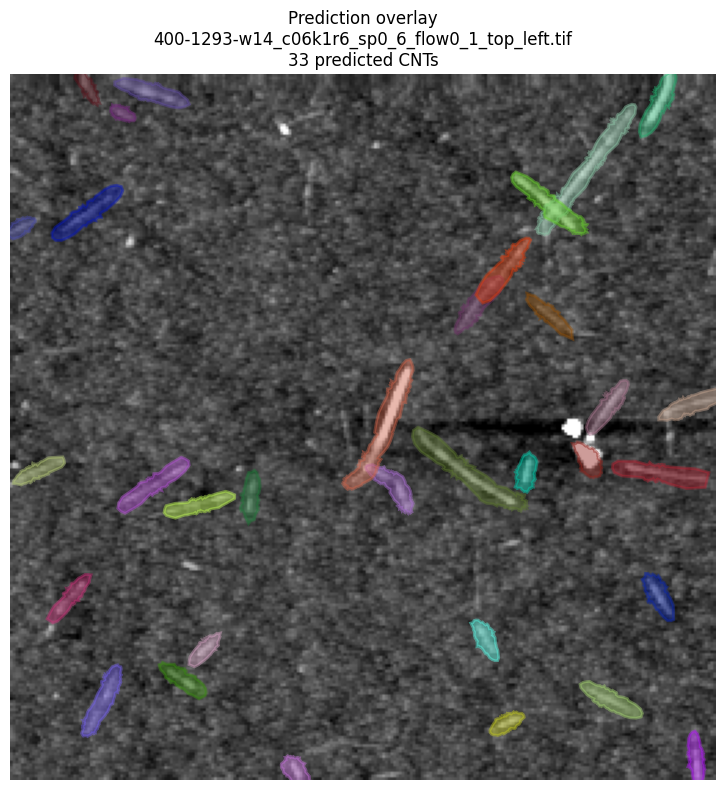

In [31]:
from cnt_project.coco.overlay import overlay_annotations_on_ax
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image, cmap="gray")

overlay_annotations_on_ax(
    ax,
    pred_anns,
    alpha=0.45,
)

ax.set_title(
    f"Prediction overlay\n{worst_filename}\n"
    f"{len(pred_anns)} predicted CNTs"
)

ax.axis("off")
plt.tight_layout()
plt.show()

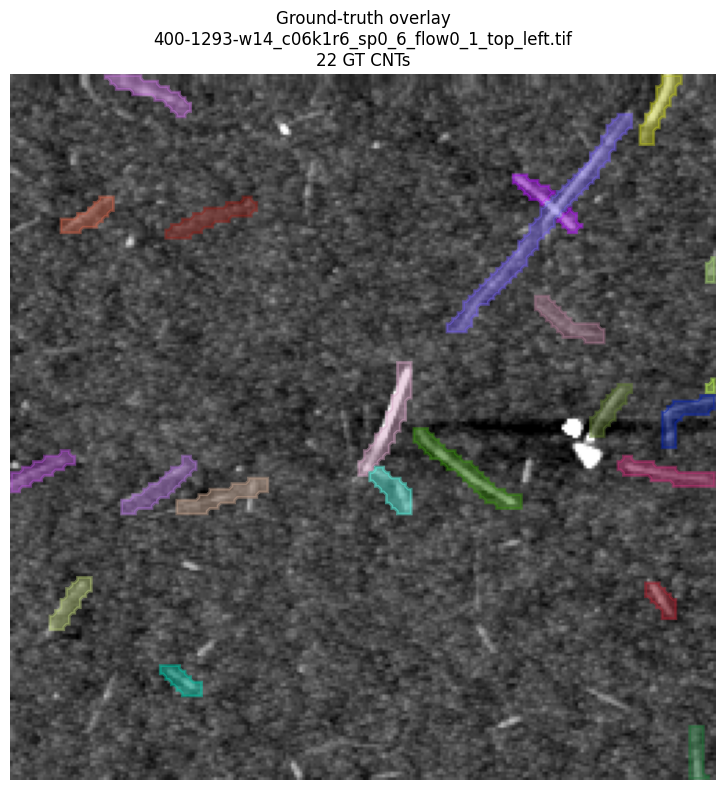

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image, cmap="gray")

overlay_annotations_on_ax(
    ax,
    gt_anns,
    alpha=0.45,
)

ax.set_title(
    f"Ground-truth overlay\n{worst_filename}\n"
    f"{len(gt_anns)} GT CNTs"
)

ax.axis("off")
plt.tight_layout()
plt.show()

In [33]:
from cnt_project.features.core.cnt_feature_extraction import (
    compute_line_densities_from_polygons,
)

image_height = int(gt_image_record.get("height", 256))
image_width = int(gt_image_record.get("width", 256))

gt_line_density = compute_line_densities_from_polygons(
    annotations=gt_anns,
    image_height=image_height,
    image_width=image_width,
)

pred_line_density = compute_line_densities_from_polygons(
    annotations=pred_anns,
    image_height=image_height,
    image_width=image_width,
)
gt_line_density = np.asarray(gt_line_density, dtype=float)
pred_line_density = np.asarray(pred_line_density, dtype=float)

In [34]:
row_error = pred_line_density - gt_line_density

print("Mean signed row error:", row_error.mean())
print("Mean absolute row error:", np.abs(row_error).mean())
print("Maximum absolute row error:", np.abs(row_error).max())

Mean signed row error: 0.46484375
Mean absolute row error: 0.72265625
Maximum absolute row error: 3.0


### Visual comparison at the row with the largest GT-vs-prediction
### line-density discrepancy.

Image: 400-1293-w14_c06k1r6_sp0_6_flow0_1_top_left.tif
Worst row: 144
GT intersections: 6
Predicted intersections: 9
Difference (prediction - GT): +3


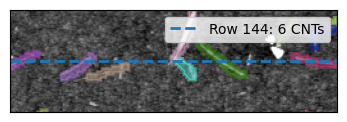

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_reference_annotation_row_overlay.svg


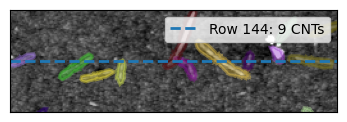

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\operational_limit_prediction_annotation_row_overlay.svg


In [35]:
row_difference = pred_line_density - gt_line_density
worst_row = int(np.argmax(np.abs(row_difference)))

gt_count = int(gt_line_density[worst_row])
pred_count = int(pred_line_density[worst_row])
signed_difference = int(row_difference[worst_row])

print(f"Image: {worst_filename}")
print(f"Worst row: {worst_row}")
print(f"GT intersections: {gt_count}")
print(f"Predicted intersections: {pred_count}")
print(f"Difference (prediction - GT): {signed_difference:+d}")


# ---------------------------------------------------------
# Figure settings
# ---------------------------------------------------------

zoom_half_height = 40

y_min = max(0, worst_row - zoom_half_height)
y_max = min(image.shape[0] - 1, worst_row + zoom_half_height)

figure_size = FIG_SIZES["double_half"]

SAVE_REFERENCE_OVERLAY = (
    OUTPUTS["density"]
    / "operational_limit_reference_annotation_row_overlay.svg"
)

SAVE_PREDICTION_OVERLAY = (
    OUTPUTS["density"]
    / "operational_limit_prediction_annotation_row_overlay.svg"
)

SAVE_REFERENCE_OVERLAY.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------
# Reference / ground-truth figure
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=figure_size,
)

ax.imshow(
    image,
    cmap="gray",
)

overlay_annotations_on_ax(
    ax,
    gt_anns,
    alpha=0.45,
    seed=42,
)

ax.axhline(
    worst_row,
    linestyle="--",
    linewidth=2,
    label=f"Row {worst_row}: {gt_count} CNTs",
)

ax.set_xlim(
    0,
    image.shape[1],
)

# Image coordinates increase downward.
ax.set_ylim(
    y_max,
    y_min,
)

ax.set_xticks([])
ax.set_yticks([])

ax.legend(
    loc="upper right",
)

fig.tight_layout(pad=0.1)

fig.savefig(
    SAVE_REFERENCE_OVERLAY,
    format="svg",
)

plt.show()
plt.close(fig)

print("Saved:", SAVE_REFERENCE_OVERLAY)


# ---------------------------------------------------------
# Prediction figure
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=figure_size,
)

ax.imshow(
    image,
    cmap="gray",
)

overlay_annotations_on_ax(
    ax,
    pred_anns,
    alpha=0.45,
    seed=123,
)

ax.axhline(
    worst_row,
    linestyle="--",
    linewidth=2,
    label=f"Row {worst_row}: {pred_count} CNTs",
)

ax.set_xlim(
    0,
    image.shape[1],
)

ax.set_ylim(
    y_max,
    y_min,
)

ax.set_xticks([])
ax.set_yticks([])

ax.legend(
    loc="upper right",
)

fig.tight_layout(pad=0.1)

fig.savefig(
    SAVE_PREDICTION_OVERLAY,
    format="svg",
)

plt.show()
plt.close(fig)

print("Saved:", SAVE_PREDICTION_OVERLAY)